# 260826 machine leanring
[machine learning chapter02-1]

---

## 1. Today's Goal

- 오늘 배운 내용 복습

---

## 2. Key Concepts

# 선형 회귀 모델 학습 흐름

정확한 예측 모델이 나올 때까지 1~4 과정을 반복한다.

## 1. 예측값 계산

$$
\hat{y} = wx + b
$$

- $\hat{y}$: 모델 예측값
- $w$: 가중치(기울기)
- $x$: feature(입력값)
- $y$: label(실제값)
- $b$: 편향(bias), 절편, 기본값

예: 아파트 가격 예측 모델

- 평수: $x$
- 실거래가: $y$
- 평수가 1 증가할 때 예측 가격이 변하는 양: $w$
- 평수와 무관한 기본 가격: $b$
- 모델이 예측한 아파트 가격: $\hat{y}$

## 2. Loss 계산

**Loss(손실)**는 실제값과 예측값의 차이인 오차들을 하나의 값으로 요약한 것이다.

- Loss가 작을수록 예측값이 실제값에 더 가깝다.
- 학습의 목표는 Loss를 가능한 작게 만드는 것이다.
- Loss function: Loss를 계산하는 공식

### MSE: 평균제곱오차

$$
\mathrm{MSE} =
\frac{1}{n}\sum_{i=1}^{n}
\left(y_i - \hat{y}_i\right)^2
$$

- 각 오차를 제곱한 뒤 평균을 낸다.
- 큰 오차에 더 큰 패널티를 준다.
- 이상치에 민감하다.

### MAE: 평균절대오차

$$
\mathrm{MAE} =
\frac{1}{n}\sum_{i=1}^{n}
\left|y_i - \hat{y}_i\right|
$$

- 각 오차의 절댓값을 평균 낸다.
- MSE보다 이상치의 영향이 작다.

---> MSE, MAE: 회귀선의 예측 성능을 평가하는 값. 여러 선형회귀 모델을 비교하거나 한 모델의 예측 오차를 평가할 때 쓰임


### Huber Loss (Smmoth L1)

- 오차가 작을 땐 MSE, 오차가 클 땐 MAE로 동작하는 하이브리드 손실 함수
- 두 손실 함수의 장점을 결합한 대안 손실 함수

## 3. 기울기(Gradient) 계산

Loss를 $w$, $b$에 대해 각각 편미분해 Loss가 증가하는 방향과 변화량을 구한다.

$$
\frac{\partial \mathrm{Loss}}{\partial w},
\quad
\frac{\partial \mathrm{Loss}}{\partial b}
$$

- 기울기가 양수: 해당 값을 줄이는 방향으로 이동
- 기울기가 음수: 해당 값을 늘리는 방향으로 이동
- 역전파(backpropagation): 출력의 Loss로부터 시작해 각 가중치가 Loss에 미친 영향을 거꾸로 계산하는 방법  
  - 선형회귀에서는 기울기를 직접 계산할 수 있지만, 신경망에서는 역전파가 핵심이다.

## 4. $w$, $b$ 업데이트
-  learning rate, optimizer가 업데이트 방법·크기 결정
$$
w_{\text{new}}
=
w_{\text{old}}
-
\alpha
\cdot
\frac{\partial \mathrm{Loss}}{\partial w}
$$

$$
b_{\text{new}}
=
b_{\text{old}}
-
\alpha
\cdot
\frac{\partial \mathrm{Loss}}{\partial b}
$$

$\alpha$는 학습률(learning rate)로, 한 번 업데이트할 때 이동하는 크기이다.

### Model Parameter

모델이 학습을 통해 구하는 값

- w(weight) 가중치, b(bias) 편향/기울기

### Hyperparameter

모델이 데이터로부터 직접 학습하는 값이 아니라, 개발자가 학습 전에 설정하거나 학습 결과를 보며 조정하는 값이다.

- learning rate(학습률) (α): 기울기 방향으로 얼마나 크게 업데이트할지 결정
- epochs(전체 데이터 학습 반복 횟수, 1~4 과정을 몇 번 반복할지 결정) 
- batch size(한 번에 학습에 사용하는 데이터 수)

### Optimizer

기울기를 이용해 $w$, $b$를 효율적으로 업데이트하는 방법이다.

- Gradient Descent
- SGD (Stochastic Gradient Descent)
- Momentum
- RMSprop: 적응형 학습률(Adaptive Learing Rate) 알고리즘 -> 최근 기울기 변화량 추적, 가중치별 보폭 조절 
- Adam

아주 쉽게 설명?

선형회귀 학습: 대충 직선 그리고, 실제 데이터랑 비교하고, 틀린 정도만큼 직선 조금씩 수정하는 과정

1. 예측한다
   → 현재 w, b로 직선을 그린다.
   → ŷ = wx + b

2. 얼마나 틀렸는지 확인한다
   → 실제값 y와 예측값 ŷ의 차이를 계산한다. 'Error'
   → MSE 또는 MAE로 Loss를 구한다.  <-----'Error' 오차들을 사용

3. 어느 방향으로 고쳐야 하는지 계산한다
   → w와 b를 늘릴지 줄일지 기울기(Gradient)로 판단한다.

4. 직선을 조금 수정한다
   → 학습률 α만큼 w와 b를 업데이트한다.

1~4을 여러 번 반복 epoch
   → Loss가 줄어들며 데이터에 잘 맞는 직선을 찾는다.

---

## 3. Practice 실습 코드

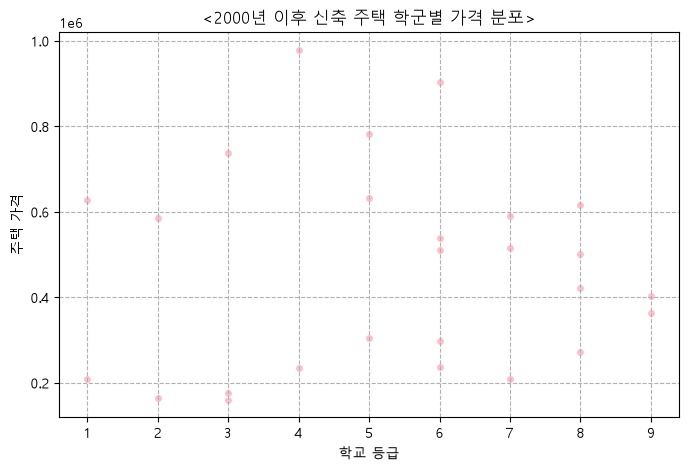

In [8]:
# 2장 1강 문제 1
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rc
import platform


os_name = platform.system()

if os_name == "Windows":
    rc("font", family="Malgun Gothic")


df = pd.read_csv("usa_housing.csv")
df = df[(df['YearBuilt'] > 2000) & (df['CrimeRate'] < 50)] #데이터 범위 줄이기 (CrimeRate 범위 조건 추가)


# 2000보다 큰 YearBuilt 컬럼 값 df에 저장


plt.figure(figsize=(8, 5))
plt.scatter(
    df['SchoolRating'],
    df['Price'],
    color='pink',
    edgecolor='w'
)

plt.title("<2000년 이후 신축 주택 학군별 가격 분포>")
plt.xlabel("학교 등급")
plt.ylabel("주택 가격")
plt.grid(True, linestyle='--')
plt.show()



In [ ]:
# 2장 1강 문제 2
from sklearn.linear_model import LinearRegression # 선형회귀 학습을 위한 library import


X = df[['SchoolRating']] # feature입력값, 2차원 DataFrame 구조로 추출할 경우 대괄호 2개
y = df['Price'] # label실제값, Series 형태로 추출할 경우 대괄호 1개

model = LinearRegression() #선형회귀 모델 model 생성
model.fit(X, y); # 내부적으로 1~4 학습 진행: Loss가 최소가 될 수 있도록 최적의 w, b를 찾는 단계

print("기울기(w):", model.coef_)
print("기본값(b):", model.intercept_)


기울기(w): [3536.64698128]
기본값(b): 441970.3872923807


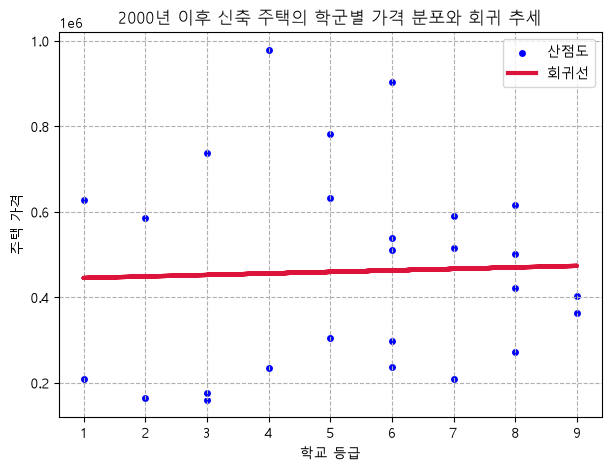

MSE: 52156139852.93538
MAE: 195205.7669593786


In [6]:
# 2장 1강 문제 3
from  sklearn.metrics import mean_squared_error, mean_absolute_error

y_pred = model.predict(X) # 학습된 w, b(모델 객체 model) 를 이용해 가격 예측값, 즉 y hat 계산

# 시각화
# 캔버스 사이즈 정하기
plt.figure(figsize=(7, 5))

# 실제 데이터 산점도
plt.scatter(                
    df['SchoolRating'],
    df['Price'],
    color='blue',
    edgecolor='w',
    label='산점도'
)

#회귀선
plt.plot(X, y_pred, color="crimson", linewidth=3, label='회귀선') # 그릴 회귀선 = y_pred
plt.xlabel("학교 등급")
plt.ylabel("주택 가격")
plt.grid(True, linestyle='--')
plt.title('2000년 이후 신축 주택의 학군별 가격 분포와 회귀 추세')
plt.legend()
plt.show()

# 평균제곱오차(MSE)와 평균절대오차(MAE) 계산 및 출력
# 선형회귀모델 성능 평가
mse = mean_squared_error(y, y_pred)
mae = mean_absolute_error(y, y_pred)
print("MSE:", mse)
print("MAE:", mae) 
# 계산한 MSE, MAE 값은 학습 전후 성능 비교, 여러 모델 중 더 좋은 모델 선택(값이 더작은 모델), 실제 서비스에서 예측이 평균적으로 얼마만큼 틀리는지 설명할 때 사용


--- 
## 4. Daily Quest

> 1. 선형 회귀 모델에서 인공지능이 학습을 통해 궁극적으로 찾고자 하는 것은 무엇입니까?

답:

> 2. 오차를 제곱하여 평균을 내며, 이상치(큰 오차)에 매우 민감하게 반응하는 손실 함수(평가지표)의 이름은 무엇입니까?

답: 

> 3. 경사하강법의 가중치 업데이트 공식 w_new = w_old - α·(∂J/∂w) 에서, 기울기(∂J/∂w) 앞에 마이너스(-) 부호가 붙는 이유로 가장 적절한 것은 무엇입니까?

답: 

> 4. 학습률(Learning Rate)이 너무 클 때 발생할 수 있는 문제로 가장 적절한 것은 무엇입니까?

답: 

> 5. 인공지능이 훈련을 시작하기 전에 사람이 미리 정해주어야 하는 값으로, 학습률이나 학습 횟수(Epochs)가 대표적인 예시인 이 용어는 무엇입니까?

오답: optimizer
답: hyperparameter

--- 
## 5. Reflection

- 선형회귀 모델 학습 순서 기억하기!
- AI를 이용한 웹개발 공모전에 참여하려고 하는데, AI서비스를 사용하니 10분만에 거의 프로젝트의 50%를 완성해버렸다...코딩을 잘하는것보단 어떻게 서비스를 기획하는지 역량이 더 중요함을 새삼 체감했다...
- 오늘부터 그룹스터디가 진행되는데, 항상 혼자 공부해온 나로서는 좀 불편하다.. 매주 발표는 많은 도움이 될 것 같지만 자습 시간엔 좀 더 학습에 집중하고 싶다.
- 하지만 더이상 코딩실력만으로는 개발자가 될 수 없기에 다른 수강생들과 함께 공부하는 것도 면접준비나 관련 정보얻기 등등에 많은 도움이 된다고 생각한다..!